# 5000-cycle projections for the 7 confirmed anchors

Fitted-θ Phase 2 sims were validated over the measured horizon (150–400 cy). This notebook extrapolates each anchor to **5000 cycles** to check the fits produce physically-plausible long-horizon degradation.

**What to look for:**

- Smooth monotonic fade (no cliffs, plateaus, or oscillations)
- **EoL at SoH = 0.80** landing between ~1500 and ~5000 cycles (LFP datasheet range at moderate C-rate)
- No premature sim death (< 1000 cycles) — those flag over-aggressive θ (LAM eating anode porosity)

Any anchor whose 5000-cy trajectory looks unphysical is a red flag for using it as a Phase 3 perturbation seed.

In [1]:
import sys, time, yaml, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
HERE = Path('/home/hj/Desktop/PINNs/Voltaris/Data_Exploration')
sys.path.insert(0, str(HERE))
import phase2_de_fit as p2

ANCHORS = [
    ('CALB', '0003'), ('CALB', '0009'), ('CALB', '0010'), ('CALB', '0015'),
    ('EVE',  '0004'),
    ('REPT', '0007'), ('REPT', '0057'),
]
MAKE_COLOR = {'CALB': '#c94a3c', 'EVE': '#4dab5c', 'REPT': '#3c7cc9'}
N_CYCLES = 5000  # projection horizon
print(f'{len(ANCHORS)} anchors to project over {N_CYCLES} cycles each')

7 anchors to project over 5000 cycles each


In [2]:
def _saved_theta_log(deg_yaml_path):
    d = yaml.safe_load(Path(deg_yaml_path).read_text())
    fp = d['fitted_params']
    order = ['k_SEI', 'V_SEI', 'D_SEI_solvent', 'k_plating', 'k_LAM_negative']
    enc = {'k_SEI':'log10','V_SEI':'linear','D_SEI_solvent':'log10',
           'k_plating':'log10','k_LAM_negative':'log10'}
    out = [np.log10(float(fp[k]['value'])) if enc[k]=='log10' else float(fp[k]['value']) for k in order]
    return np.array(out, dtype=float)

def _eol_cycle(soh_trace, threshold=0.80):
    """Return first cycle where SoH <= threshold. NaN if never crossed."""
    below = np.where(np.asarray(soh_trace) <= threshold)[0]
    return int(below[0]) if len(below) else np.nan

results = []
for make, cell in ANCHORS:
    t0 = time.time()
    print(f'  {make} {cell} ...', end='', flush=True)
    deg = f'/home/hj/Desktop/PINNs/configs/deg_params/{make}_{cell}.yaml'
    theta_log = _saved_theta_log(deg)
    ctx = p2.load_cell_context(make, cell)
    pv = p2.build_pybamm_parameters(ctx['bol'])
    pv = p2.apply_deg_params(pv, **p2._theta_from_log(theta_log))
    soh_sim = p2.simulate_soh_trajectory(pv, ctx['experiment_steps'],
                                          n_cycles=N_CYCLES,
                                          nominal_capacity_Ah=ctx['nominal_capacity_Ah'])
    finite = np.isfinite(soh_sim)
    n_finite = int(finite.sum())
    finite_soh = soh_sim[finite] if n_finite else np.array([np.nan])
    eol = _eol_cycle(finite_soh, 0.80)
    survived_fully = (n_finite == N_CYCLES)
    results.append(dict(
        make=make, cell=cell,
        soh_sim=soh_sim,
        n_finite=n_finite,
        survived_fully=survived_fully,
        final_soh=float(finite_soh[-1]) if n_finite else np.nan,
        eol_cycle=eol,
        protocol=ctx.get('protocol_id','?'),
        wall_s=time.time() - t0,
    ))
    r = results[-1]
    print(f" wall={r['wall_s']:.0f}s   coverage={n_finite}/{N_CYCLES}   final_SoH={r['final_soh']:.3f}   "
          f"EoL@0.80={'never' if not np.isfinite(eol) else str(eol)+' cy'}")
print('done')

  CALB 0003 ...

 wall=414s   coverage=5000/5000   final_SoH=0.711   EoL@0.80=2702 cy
  CALB 0009 ...

 wall=401s   coverage=5000/5000   final_SoH=0.606   EoL@0.80=1865 cy
  CALB 0010 ...

 wall=401s   coverage=5000/5000   final_SoH=0.690   EoL@0.80=2722 cy
  CALB 0015 ...

 wall=413s   coverage=5000/5000   final_SoH=0.821   EoL@0.80=never
  EVE 0004 ...

 wall=414s   coverage=5000/5000   final_SoH=0.682   EoL@0.80=2701 cy
  REPT 0007 ...

 wall=398s   coverage=5000/5000   final_SoH=0.732   EoL@0.80=3217 cy
  REPT 0057 ...

 wall=452s   coverage=5000/5000   final_SoH=0.779   EoL@0.80=4318 cy
done


## 5000-cycle projected SoH per anchor

Dotted horizontal at SoH = 0.80 (EoL). Dashed vertical at first EoL crossing if any.

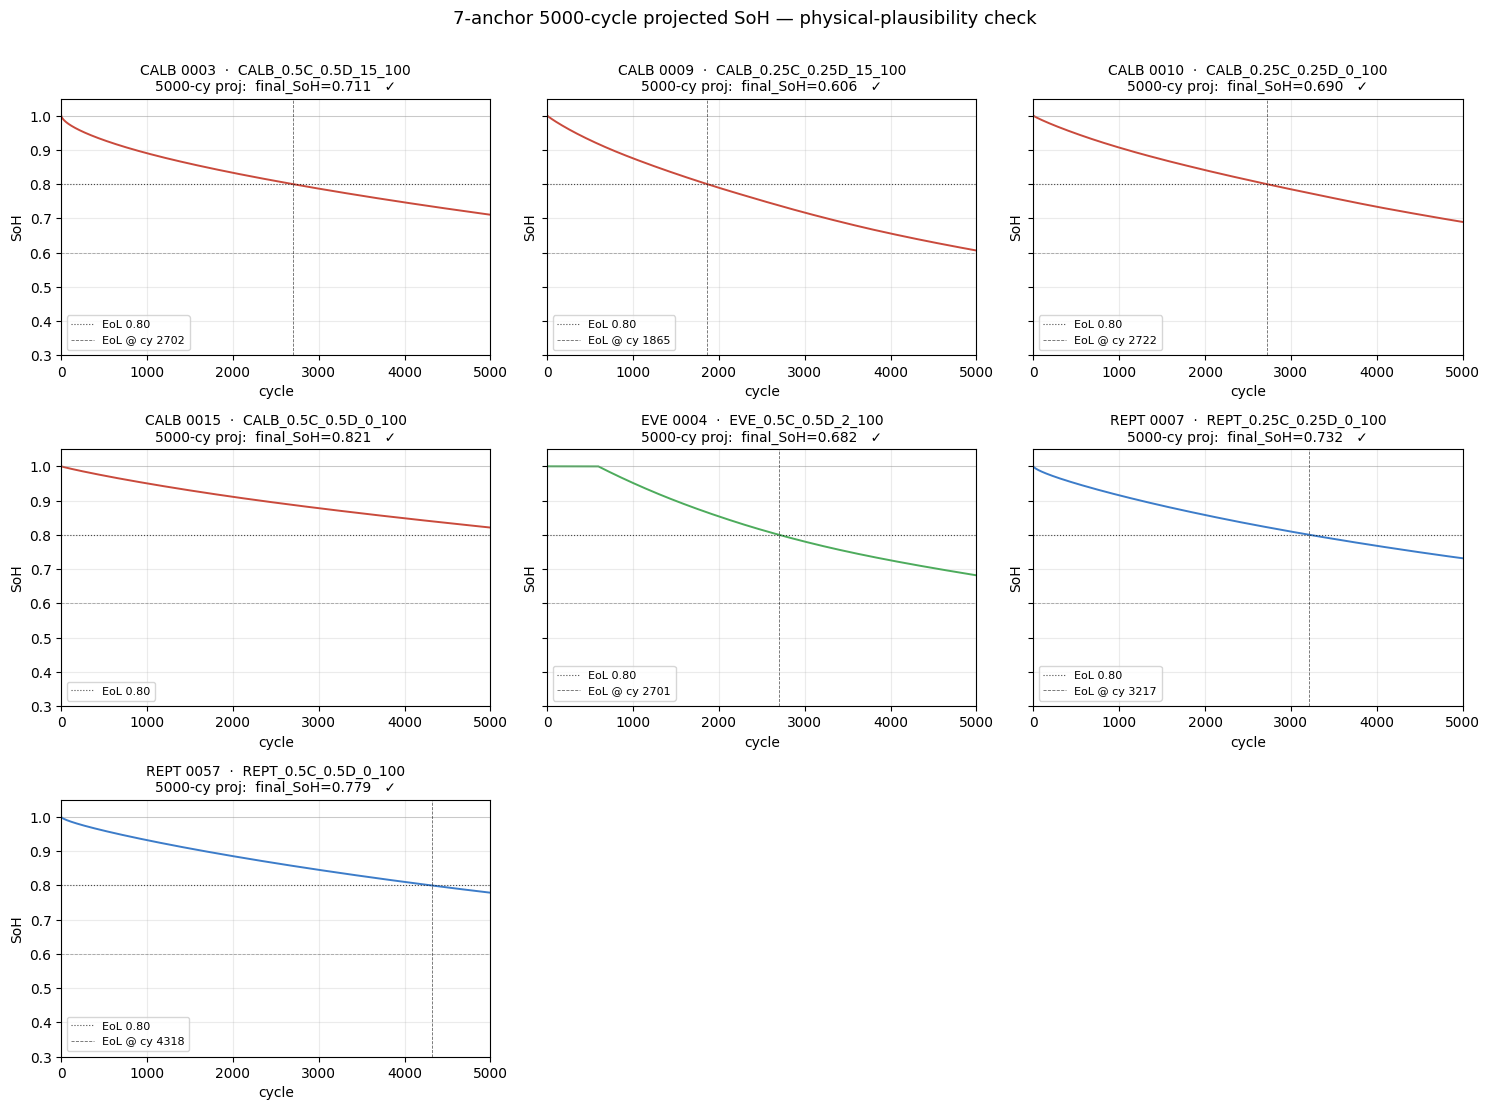

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharey=True)
axes = axes.ravel()
for i, r in enumerate(results):
    ax = axes[i]
    color = MAKE_COLOR[r['make']]
    n = r['n_finite']
    x = np.arange(n)
    y = np.asarray(r['soh_sim'])[:n]
    ax.plot(x, y, color=color, lw=1.4)
    ax.axhline(0.80, color='k', ls=':', lw=0.8, alpha=0.7, label='EoL 0.80')
    ax.axhline(1.00, color='0.55', ls='-', lw=0.5, alpha=0.5)
    ax.axhline(0.60, color='0.35', ls='--', lw=0.6, alpha=0.5)
    if np.isfinite(r['eol_cycle']):
        ax.axvline(r['eol_cycle'], color='k', ls='--', lw=0.6, alpha=0.6,
                    label=f"EoL @ cy {r['eol_cycle']}")
    survived = '✓' if r['survived_fully'] else f"died at cy {n}"
    ax.set_title(f"{r['make']} {r['cell']}  ·  {r['protocol']}\n"
                 f"5000-cy proj:  final_SoH={r['final_soh']:.3f}   {survived}",
                 fontsize=10)
    ax.set_xlim(0, 5000)
    ax.set_ylim(0.3, 1.05)
    ax.set_xlabel('cycle')
    ax.set_ylabel('SoH')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc='lower left')
for j in range(len(results), len(axes)):
    axes[j].axis('off')
fig.suptitle('7-anchor 5000-cycle projected SoH — physical-plausibility check',
              y=1.005, fontsize=13)
fig.tight_layout()
plt.show()

In [4]:
rows = []
for r in results:
    verdict = 'CLEAN' if r['survived_fully'] and np.isfinite(r['eol_cycle']) and 1500 <= r['eol_cycle'] <= 5000 else (
        'EARLY DEATH' if not r['survived_fully'] else
        'NO FADE' if np.isnan(r['eol_cycle']) else
        'FAST FADE (EoL < 1500 cy)'
    )
    rows.append(dict(
        make=r['make'], cell=r['cell'], protocol=r['protocol'],
        n_finite=r['n_finite'], survived=r['survived_fully'],
        final_SoH=round(r['final_soh'], 4),
        EoL_cycle=r['eol_cycle'] if np.isfinite(r['eol_cycle']) else 'never',
        verdict=verdict,
        wall_s=round(r['wall_s'], 1),
    ))
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(HERE / 'phase2_anchor_5000cy_summary.csv', index=False)
print(f'\nWrote {HERE / "phase2_anchor_5000cy_summary.csv"}')

make cell                protocol  n_finite  survived  final_SoH EoL_cycle verdict  wall_s
CALB 0003   CALB_0.5C_0.5D_15_100      5000      True     0.7107      2702   CLEAN   413.6
CALB 0009 CALB_0.25C_0.25D_15_100      5000      True     0.6063      1865   CLEAN   401.5
CALB 0010  CALB_0.25C_0.25D_0_100      5000      True     0.6898      2722   CLEAN   401.3
CALB 0015    CALB_0.5C_0.5D_0_100      5000      True     0.8212     never NO FADE   412.6
 EVE 0004     EVE_0.5C_0.5D_2_100      5000      True     0.6818      2701   CLEAN   414.3
REPT 0007  REPT_0.25C_0.25D_0_100      5000      True     0.7317      3217   CLEAN   398.4
REPT 0057    REPT_0.5C_0.5D_0_100      5000      True     0.7790      4318   CLEAN   451.9

Wrote /home/hj/Desktop/PINNs/Voltaris/Data_Exploration/phase2_anchor_5000cy_summary.csv
